___

<a href='http://www.pieriandata.com'> <img src='../Pierian_Data_Logo.png' /></a>
___

# K Nearest Neighbors Project 

Welcome to the KNN Project! This will be a simple project very similar to the lecture, except you'll be given another data set. Go ahead and just follow the directions below.
## Import Libraries
**Import pandas,seaborn, and the usual libraries.**

In [45]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Get the Data
** Read the 'KNN_Project_Data csv file into a dataframe **

In [46]:
df = pd.read_csv('KNN_Project_Data')

**Check the head of the dataframe.**

In [47]:
df.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


# EDA

Since this data is artificial, we'll just do a large pairplot with seaborn.

**Use seaborn on the dataframe to create a pairplot with the hue indicated by the TARGET CLASS column.**

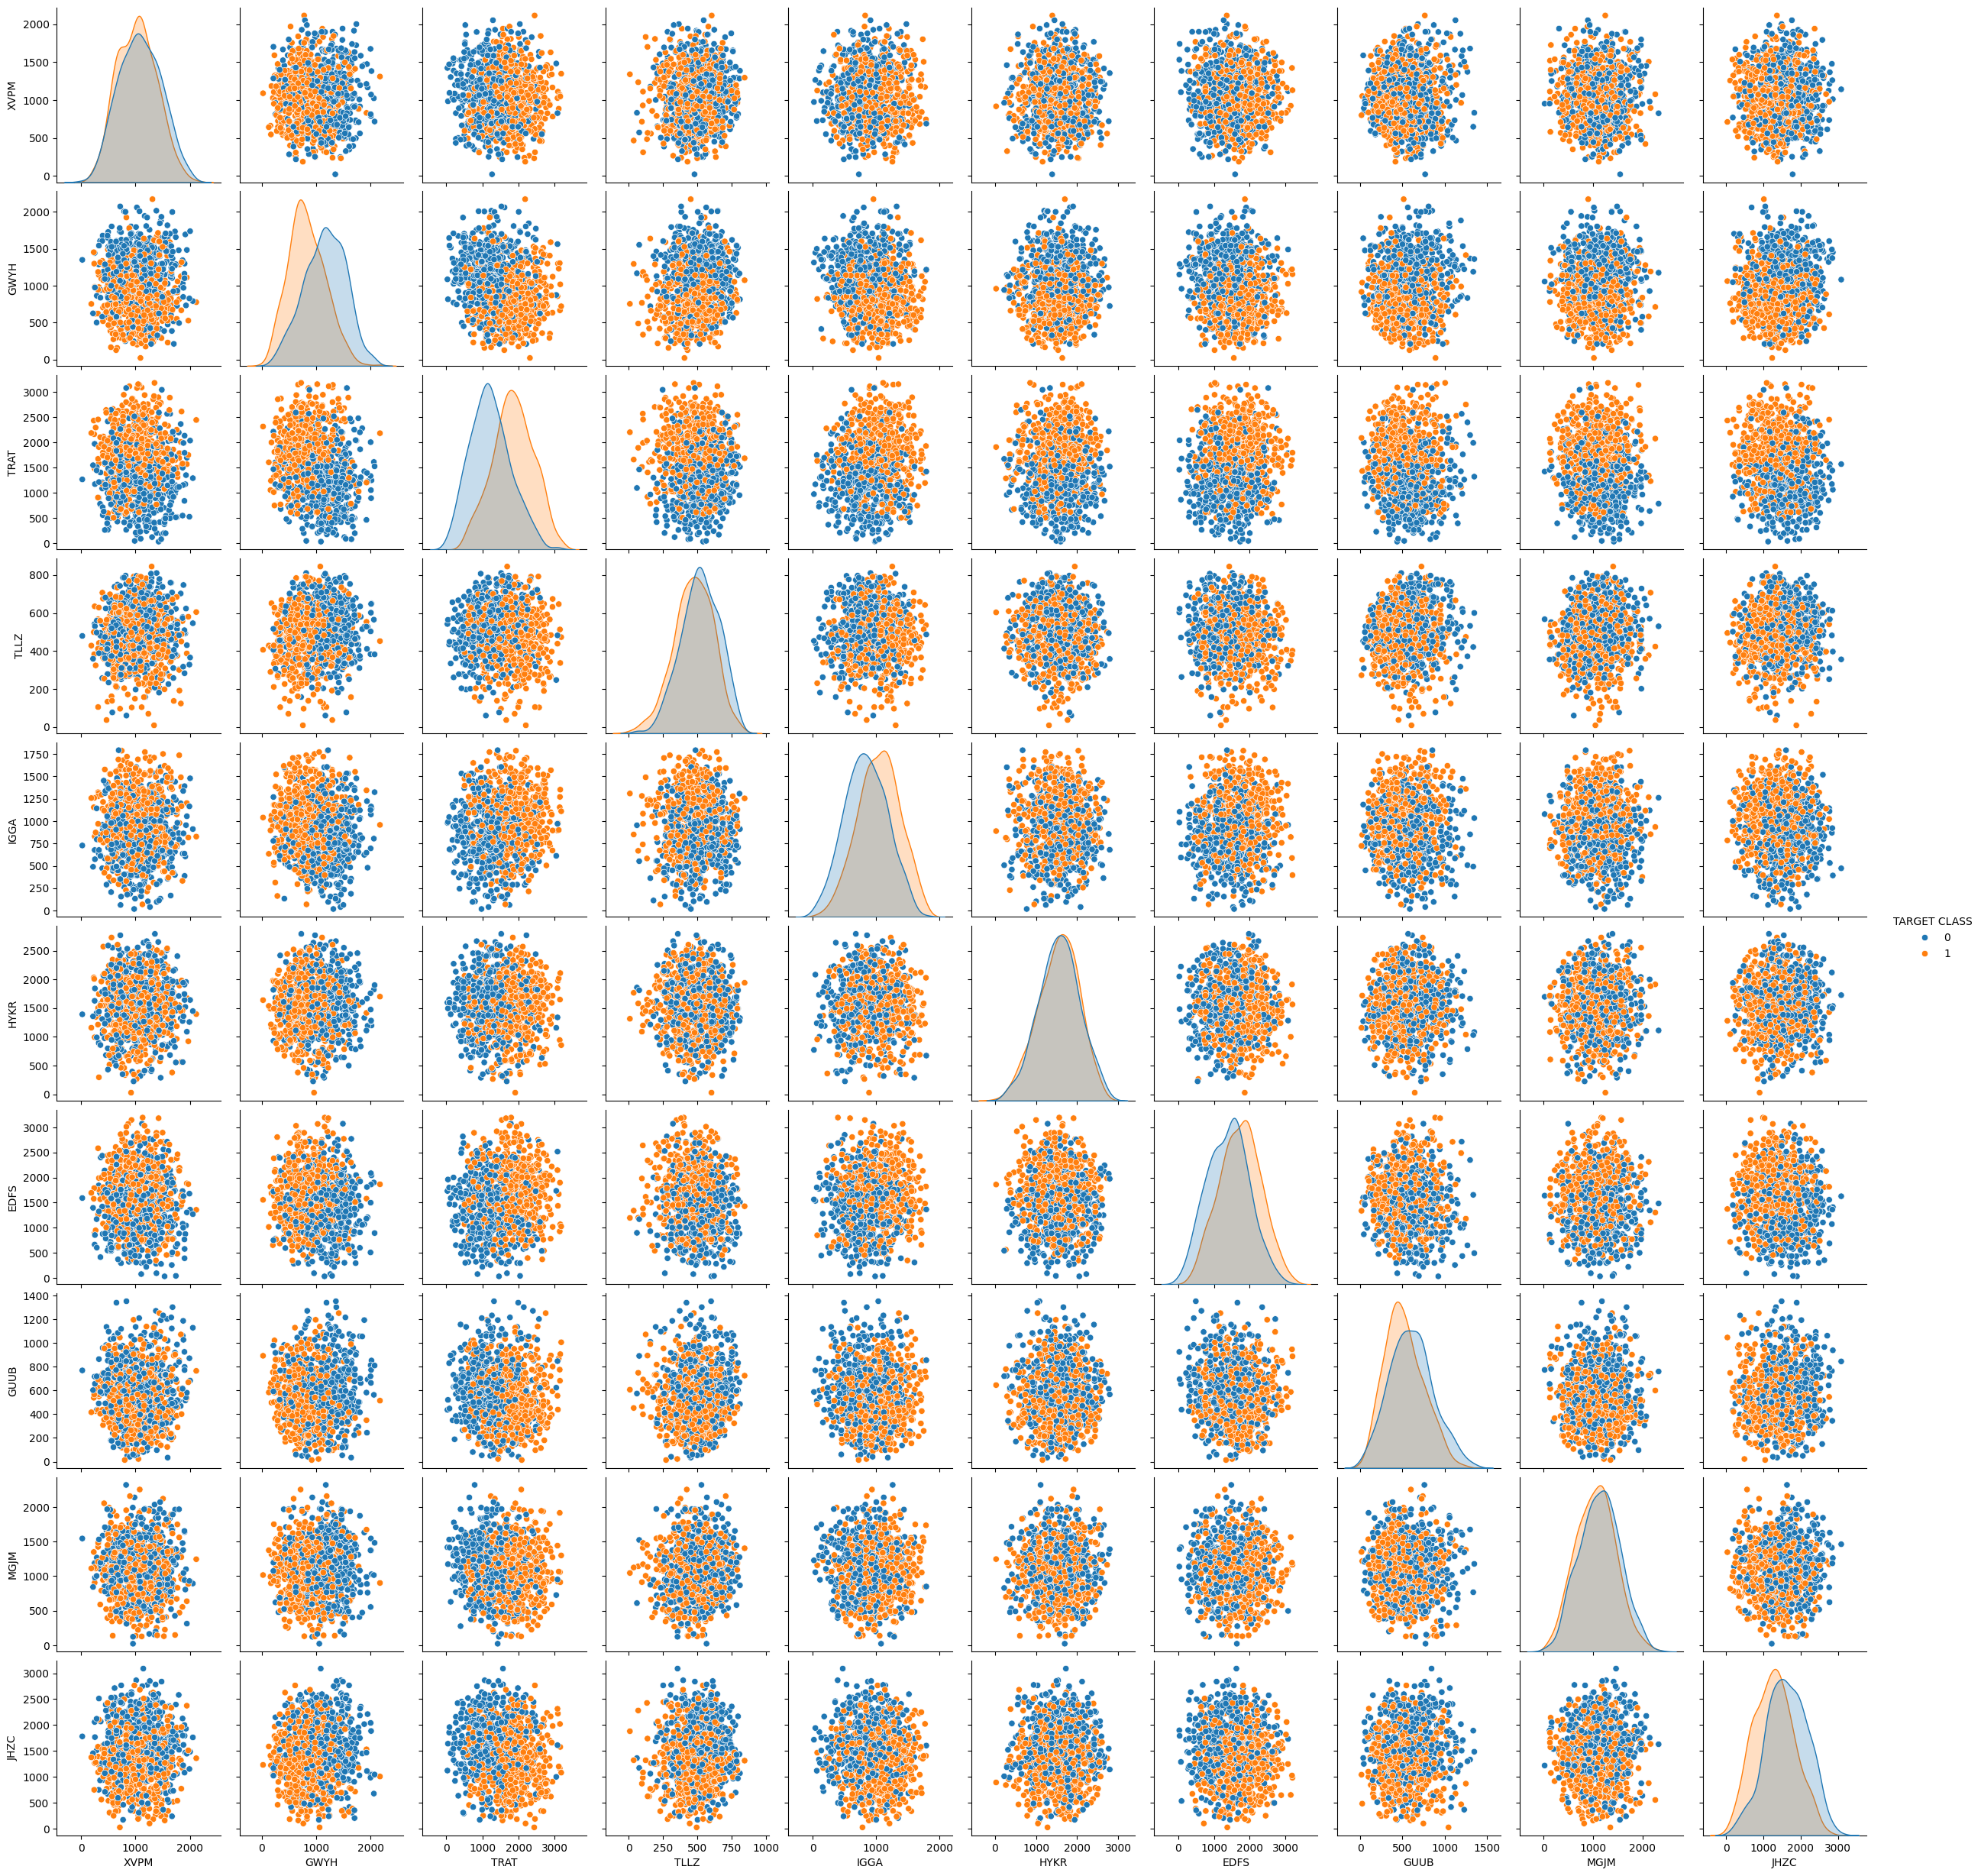

In [48]:
sns.pairplot(data=df, hue='TARGET CLASS')

# Standardize the Variables

Time to standardize the variables.

** Import StandardScaler from Scikit learn.**

In [49]:
from sklearn.preprocessing import StandardScaler

** Create a StandardScaler() object called scaler.**

In [50]:
scaler = StandardScaler()

** Fit scaler to the features.**

In [51]:
scaler.fit(df.drop('TARGET CLASS', axis=1))

StandardScaler()

**Use the .transform() method to transform the features to a scaled version.**

In [52]:
scaled_features = scaler.transform(df.drop('TARGET CLASS', axis=1))

**Convert the scaled features to a dataframe and check the head of this dataframe to make sure the scaling worked.**

In [53]:
scaled_df = pd.DataFrame(scaled_features, columns=df.columns[:-1])

# Train Test Split

**Use train_test_split to split your data into a training set and a testing set.**

In [54]:
X = scaled_df
y = df['TARGET CLASS']
from sklearn.model_selection import train_test_split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=103, train_size=0.3)

# Using KNN

**Import KNeighborsClassifier from scikit learn.**

In [56]:
from sklearn.neighbors import KNeighborsClassifier

**Create a KNN model instance with n_neighbors=1**

In [57]:
knn = KNeighborsClassifier(n_neighbors=1)

**Fit this KNN model to the training data.**

In [58]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

# Predictions and Evaluations
Let's evaluate our KNN model!

**Use the predict method to predict values using your KNN model and X_test.**

In [59]:
predictions = knn.predict(X_test)

** Create a confusion matrix and classification report.**

In [60]:
from sklearn.metrics import confusion_matrix, classification_report

In [61]:
print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.71      0.68      0.69       344
           1       0.70      0.73      0.71       356

    accuracy                           0.70       700
   macro avg       0.70      0.70      0.70       700
weighted avg       0.70      0.70      0.70       700



In [62]:
print(confusion_matrix(y_test, predictions))

[[234 110]
 [ 97 259]]


# Choosing a K Value
Let's go ahead and use the elbow method to pick a good K Value!

** Create a for loop that trains various KNN models with different k values, then keep track of the error_rate for each of these models with a list. Refer to the lecture if you are confused on this step.**

In [63]:
error_rate = []

for i in range(1, 60):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

**Now create the following plot using the information from your for loop.**

ValueError: x and y must have same first dimension, but have shapes (39,) and (59,)

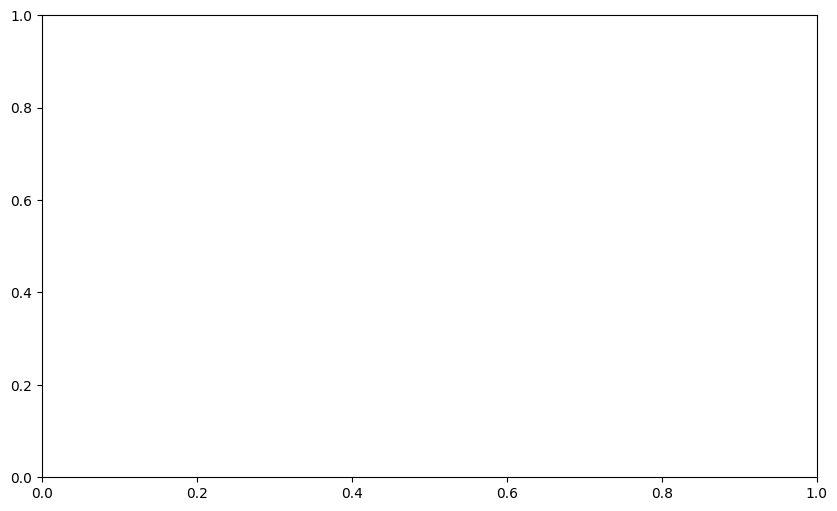

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate)

## Retrain with new K Value

**Retrain your model with the best K value (up to you to decide what you want) and re-do the classification report and the confusion matrix.**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=30)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[283  61]
 [ 61 295]]
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       344
           1       0.83      0.83      0.83       356

    accuracy                           0.83       700
   macro avg       0.83      0.83      0.83       700
weighted avg       0.83      0.83      0.83       700



# Great Job!